Rozpoczęcie eksperymentów (bez ostrzeżeń)...

=== Regularyzacja L2 (Ridge), C=0.01 ===
F1-score (Trening): 0.5368
F1-score (Test):     0.5675
Wagi (Współczynniki): [[0.85027419 0.66055964]]

-> Zapisano wykres: surface_L2_C_0.01.png


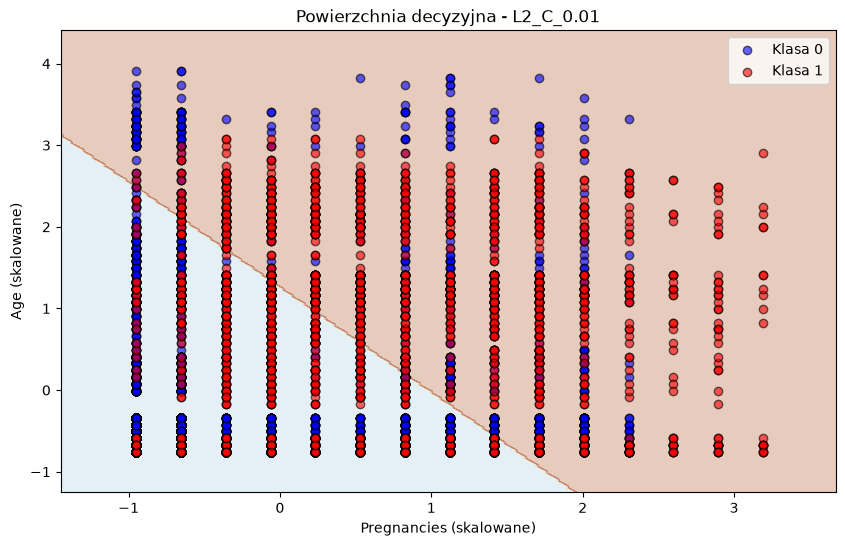

=== Regularyzacja L2 (Ridge), C=1.0 ===
F1-score (Trening): 0.5469
F1-score (Test):     0.5809
Wagi (Współczynniki): [[0.9036507  0.70097666]]

-> Zapisano wykres: surface_L2_C_1.0.png


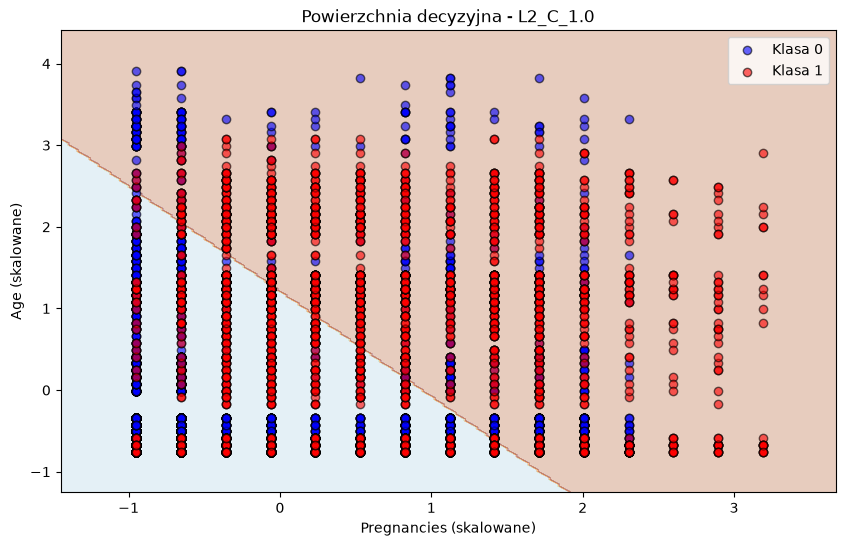

=== Regularyzacja L2 (Ridge), C=100.0 ===
F1-score (Trening): 0.5469
F1-score (Test):     0.5809
Wagi (Współczynniki): [[0.90422828 0.70136285]]

-> Zapisano wykres: surface_L2_C_100.0.png


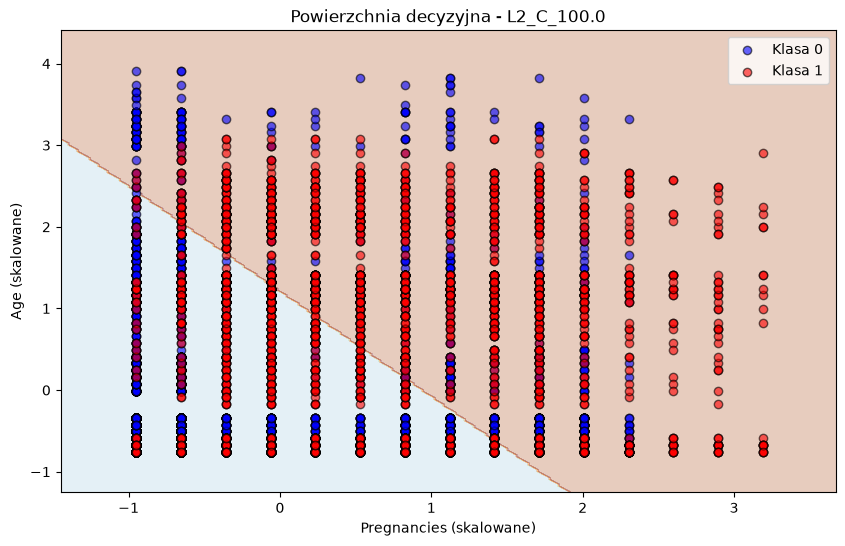

=== Regularyzacja L1 (Lasso), C=0.01 ===
F1-score (Trening): 0.5353
F1-score (Test):     0.5672
Wagi (Współczynniki): [[0.83993356 0.64185337]]

-> Zapisano wykres: surface_L1_C_0.01.png


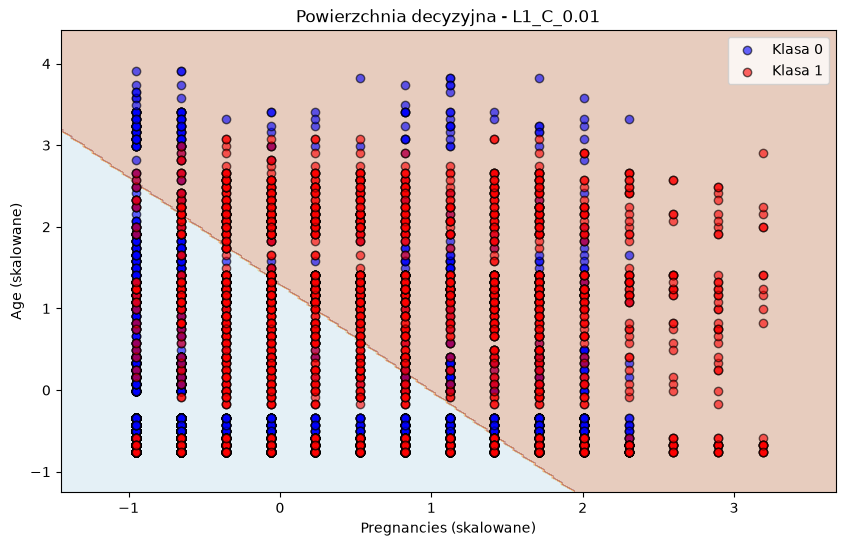

=== Regularyzacja L1 (Lasso), C=1.0 ===
F1-score (Trening): 0.5469
F1-score (Test):     0.5809
Wagi (Współczynniki): [[0.90356632 0.70074931]]

-> Zapisano wykres: surface_L1_C_1.0.png


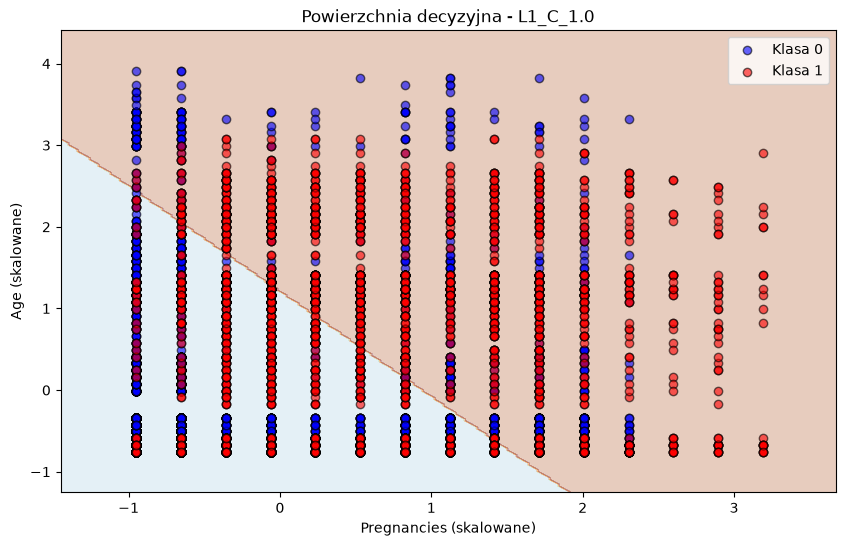


=== ZBIORCZE PORÓWNANIE REGULARYZACJI ===
Regularyzacja      C  F1_Trening  F1_Test
   L2 (Ridge)   0.01      0.5368   0.5675
   L2 (Ridge)   1.00      0.5469   0.5809
   L2 (Ridge) 100.00      0.5469   0.5809
   L1 (Lasso)   0.01      0.5353   0.5672
   L1 (Lasso)   1.00      0.5469   0.5809

-> Tabela z wynikami została zapisana jako 'wyniki_regularyzacji.csv'


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

# 1. Wczytanie danych i podział
diabetes = pd.read_csv('diabetes.csv')
features = ['Pregnancies', 'Age']
target = 'Diabetic'

X, y = diabetes[features], diabetes[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=0, stratify=y
)

# 2. Standaryzacja danych
scaler_2var = StandardScaler()
X_train_standardized = scaler_2var.fit_transform(X_train)
X_test_standardized = scaler_2var.transform(X_test)

# 3. Funkcja do wizualizacji i ZAPISYWANIA powierzchni decyzyjnej
def plot_classification_surface(X_plot, y_plot, trained_model, title_suffix=""):
    plt.figure(figsize=(10, 6))
    
    min1, max1 = X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5
    min2, max2 = X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5
    
    x1grid = np.arange(min1, max1, 0.02)
    x2grid = np.arange(min2, max2, 0.02)
    xx, yy = np.meshgrid(x1grid, x2grid)
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    yhat = trained_model.predict(grid)
    zz = yhat.reshape(xx.shape)
    
    plt.contourf(xx, yy, zz, cmap='Paired', alpha=0.3)
    
    y_plot_np = y_plot.to_numpy() if hasattr(y_plot, 'to_numpy') else y_plot
    colors = ['blue', 'red']
    
    for class_value in range(2):
        row_ix = np.where(y_plot_np == class_value)
        plt.scatter(
            X_plot[row_ix, 0], 
            X_plot[row_ix, 1], 
            color=colors[class_value], 
            alpha=0.6, 
            label=f'Klasa {class_value}',
            edgecolors='k'
        )
    
    plt.title(f'Powierzchnia decyzyjna - {title_suffix}')
    plt.xlabel('Pregnancies (skalowane)')
    plt.ylabel('Age (skalowane)')
    plt.legend(loc='upper right')
    
    clean_title = title_suffix.replace(' ', '_').replace(':', '').replace(',', '').replace('=', '_')
    filename = f"surface_{clean_title}.png"
    plt.savefig(filename, bbox_inches='tight')
    print(f"-> Zapisano wykres: {filename}")
    plt.show()  # <-- DOPISZ TĘ LINIJKĘ, aby wykres pojawił się w notebooku!
    plt.close()
    plt.close()

# 4. Nowoczesna definicja hiperparametrów zgodna z nowym scikit-learn
# l1_ratio=0.0 to dawne L2 (Ridge), l1_ratio=1.0 to dawne L1 (Lasso)
hyperparameters = [
    {'l1_ratio': 0.0, 'C': 0.01,  'label': 'L2_C_0.01'}, 
    {'l1_ratio': 0.0, 'C': 1.0,   'label': 'L2_C_1.0'},  
    {'l1_ratio': 0.0, 'C': 100.0, 'label': 'L2_C_100.0'}, 
    {'l1_ratio': 1.0, 'C': 0.01,  'label': 'L1_C_0.01'}, 
    {'l1_ratio': 1.0, 'C': 1.0,   'label': 'L1_C_1.0'},  
]

results_list = []

print("Rozpoczęcie eksperymentów (bez ostrzeżeń)...\n")

# 5. Główna pętla
for params in hyperparameters:
    l1_ratio = params['l1_ratio']
    C = params['C']
    label = params['label']
    
    # Przekazujemy l1_ratio bezpośrednio bez definiowania parametru 'penalty'
    model = LogisticRegression(l1_ratio=l1_ratio, C=C, solver='saga', random_state=0, max_iter=10000)
    model.fit(X_train_standardized, y_train)
    
    train_preds = model.predict(X_train_standardized)
    test_preds = model.predict(X_test_standardized)
    
    f1_train = f1_score(y_train, train_preds)
    f1_test = f1_score(y_test, test_preds)
    
    # Tłumaczenie etykiety dla czytelności w tabeli końcowej
    type_name = "L1 (Lasso)" if l1_ratio == 1.0 else "L2 (Ridge)"
    model_label = f"Regularyzacja {type_name}, C={C}"
    
    print(f"=== {model_label} ===")
    print(f"F1-score (Trening): {f1_train:.4f}")
    print(f"F1-score (Test):     {f1_test:.4f}")
    print(f"Wagi (Współczynniki): {model.coef_}\n")
    
    results_list.append({
        'Regularyzacja': type_name,
        'C': C,
        'F1_Trening': round(f1_train, 4),
        'F1_Test': round(f1_test, 4)
    })
    
    plot_classification_surface(
        X_plot=X_train_standardized, 
        y_plot=y_train, 
        trained_model=model, 
        title_suffix=label
    )

# 6. Raport końcowy
df_results = pd.DataFrame(results_list)
print("\n=== ZBIORCZE PORÓWNANIE REGULARYZACJI ===")
print(df_results.to_string(index=False))

df_results.to_csv('wyniki_regularyzacji.csv', index=False)
print("\n-> Tabela z wynikami została zapisana jako 'wyniki_regularyzacji.csv'")


### 📊 Analiza wyników i wnioski

#### 1. Stabilność i generalizacja wyników
Weźmy dla przykładu standardowy model (**L2, C=1.0**):
* **F1-score (Trening):** `0.5469`
* **F1-score (Test):** `0.5809`

Wynik na zbiorze testowym jest bardzo zbliżony, a nawet odrobinę wyższy niż na treningowym. Gdyby model był przeuczony, wynik na teście drastycznie by spadł (np. do *0.35* przy *0.85* na treningu). Wyższy wynik na teście oznacza, że model zachował **pełną zdolność do generalizacji**, a próbka testowa okazała się dla niego statystycznie odrobinę „czystsza” lub łatwiejsza do podziału.

#### 2. Dlaczego ten model nie potrafi się przeuczyć?
Regresja logistyczna, której używasz, opiera się w tym eksperymencie **tylko na 2 cechach** (`Pregnancies` i `Age`).
* Jest to prosty model liniowy.
* Na wykresie rysuje on idealnie prostą linię rozdzielającą klasy.
* Model liniowy w przestrzeni dwuwymiarowej ma zbyt małą elastyczność (ma tzw. *low variance*), by dopasować się do szumu i pojedynczych punktów. Nie potrafi „wygiąć” swojej granicy decyzyjnej wokół trudnych obserwacji.

#### 3. 🚨 Diagnoza: Niedouczenie (*Underfitting*) zamiast Przeuczenia
> **Główny wniosek:** Realnym problemem w tym badaniu nie jest *overfitting*, lecz **underfitting (niedouczenie)**.

Wyniki F1-score na poziomie ok. `0.55 - 0.58` są dość niskie (niewiele lepsze od losowego rzutu monetą). Model jest zbyt prosty, a dwie cechy to za mało, by poprawnie i ze stuprocentową pewnością zdiagnozować cukrzycę. Model „wycisnął” z wieku i liczby ciąż wszystko, co matematycznie możliwe, ale to wciąż za mało.
